# Compare Target Visibility

Compare one target visibility parquet between two roots (for example `data/targets` vs `data_earth_keepout_96/targets`).

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Edit these three values and re-run all cells
target = "55_Cnc"
root_a = Path(f"/Users/vkostov/Documents/GitHub/pandora-scheduler/output_directory/data/targets/{target}")
root_b = Path(f"/Users/vkostov/Documents/GitHub/pandora-scheduler/output_directory/data_earth_keepout_96/targets/{target}")

In [2]:
def find_target_file(root: Path, target_name: str) -> Path:
    pattern = f"Visibility for {target_name}.parquet"
    matches = list(root.rglob(pattern))
    if not matches:
        raise FileNotFoundError(f"No file matching '{pattern}' found under {root}")
    if len(matches) > 1:
        exact = [m for m in matches if m.parent.name == target_name]
        if len(exact) == 1:
            return exact[0]
        raise ValueError(f"Multiple matches for target '{target_name}' under {root}: {matches}")
    return matches[0]


def pick_join_keys(a: pd.DataFrame, b: pd.DataFrame) -> list[str]:
    if "Time(MJD_UTC)" in a.columns and "Time(MJD_UTC)" in b.columns:
        return ["Time(MJD_UTC)"]
    if {"Transit_Start", "Transit_Stop"}.issubset(a.columns) and {"Transit_Start", "Transit_Stop"}.issubset(b.columns):
        return ["Transit_Start", "Transit_Stop"]
    return []


def compare_numeric_columns(merged: pd.DataFrame, cols: list[str]) -> None:
    if not cols:
        print("No comparable numeric columns.")
        return
    print("Numeric differences (on matched rows):")
    any_reported = False
    for col in cols:
        a_col = f"{col}__a"
        b_col = f"{col}__b"
        if a_col not in merged.columns or b_col not in merged.columns:
            continue
        a_num = pd.to_numeric(merged[a_col], errors="coerce")
        b_num = pd.to_numeric(merged[b_col], errors="coerce")
        mask = a_num.notna() & b_num.notna()
        if not mask.any():
            continue
        diff = (b_num[mask] - a_num[mask]).abs()
        any_reported = True
        print(
            f"  {col}: matched={int(mask.sum())}, max_abs_diff={diff.max():.6g}, mean_abs_diff={diff.mean():.6g}"
        )
    if not any_reported:
        print("  (No numeric overlap to compare)")

In [3]:
file_a = find_target_file(root_a.resolve(), target)
file_b = find_target_file(root_b.resolve(), target)

df_a = pd.read_parquet(file_a)
df_b = pd.read_parquet(file_b)

cols_a = set(df_a.columns)
cols_b = set(df_b.columns)
common_cols = sorted(cols_a & cols_b)
only_a = sorted(cols_a - cols_b)
only_b = sorted(cols_b - cols_a)

print(f"Target: {target}")
print(f"A: {file_a}")
print(f"B: {file_b}")
print()
print(f"Rows: A={len(df_a)}, B={len(df_b)}")
print(f"Columns in common ({len(common_cols)}): {common_cols}")
if only_a:
    print(f"Columns only in A ({len(only_a)}): {only_a}")
if only_b:
    print(f"Columns only in B ({len(only_b)}): {only_b}")

join_keys = pick_join_keys(df_a, df_b)
if not join_keys:
    print("\nNo natural join key found. Falling back to index-based comparison.")
    n = min(len(df_a), len(df_b))
    merged = pd.DataFrame()
    for col in common_cols:
        merged[f"{col}__a"] = df_a[col].iloc[:n].to_numpy()
        merged[f"{col}__b"] = df_b[col].iloc[:n].to_numpy()
    print(f"Matched rows by index: {n}")
else:
    merged = df_a.merge(df_b, on=join_keys, how="inner", suffixes=("__a", "__b"))
    print(f"\nJoin keys: {join_keys}")
    print(f"Matched rows on keys: {len(merged)}")

comparable_numeric = []
for col in common_cols:
    if col in join_keys:
        continue
    if pd.api.types.is_numeric_dtype(df_a[col]) or pd.api.types.is_numeric_dtype(df_b[col]):
        comparable_numeric.append(col)

print()
compare_numeric_columns(merged, comparable_numeric)

Target: 55_Cnc
A: /Users/vkostov/Documents/GitHub/pandora-scheduler/output_directory/data/targets/55_Cnc/Visibility for 55_Cnc.parquet
B: /Users/vkostov/Documents/GitHub/pandora-scheduler/output_directory/data_earth_keepout_96/targets/55_Cnc/Visibility for 55_Cnc.parquet

Rows: A=524161, B=524161
Columns in common (7): ['Earth_Sep', 'Moon_Sep', 'SAA_Crossing', 'Sun_Sep', 'Time(MJD_UTC)', 'Time_UTC', 'Visible']

Join keys: ['Time(MJD_UTC)']
Matched rows on keys: 524161

Numeric differences (on matched rows):
  Earth_Sep: matched=524161, max_abs_diff=0, mean_abs_diff=0
  Moon_Sep: matched=524161, max_abs_diff=0, mean_abs_diff=0
  SAA_Crossing: matched=524161, max_abs_diff=0, mean_abs_diff=0
  Sun_Sep: matched=524161, max_abs_diff=0, mean_abs_diff=0
  Visible: matched=524161, max_abs_diff=1, mean_abs_diff=0.0386007


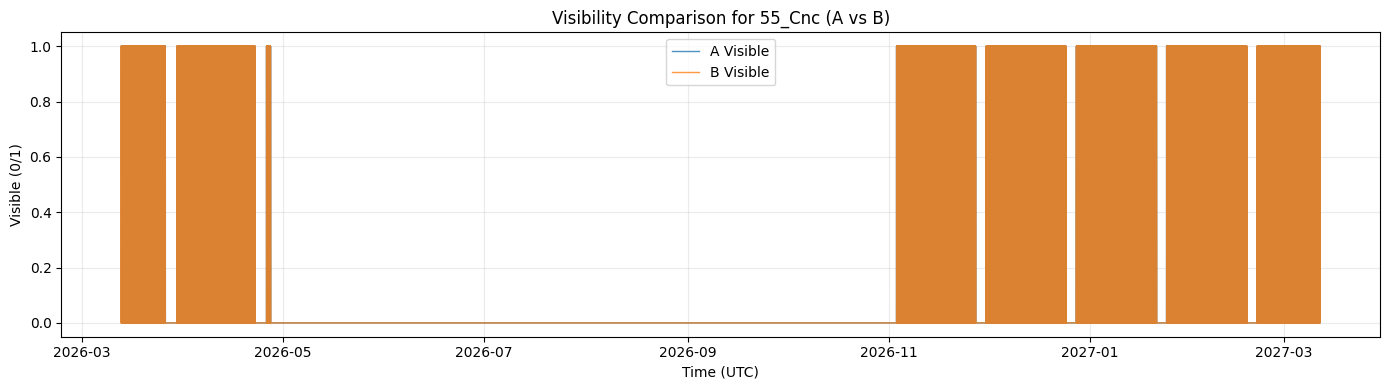

In [4]:
# Overlay plot for both visibility files
# Auto-selects a useful visualization based on available columns.

if {"Time_UTC", "Visible"}.issubset(df_a.columns) and {"Time_UTC", "Visible"}.issubset(df_b.columns):
    plot_a = df_a[["Time_UTC", "Visible"]].copy()
    plot_b = df_b[["Time_UTC", "Visible"]].copy()
    plot_a["Time_UTC"] = pd.to_datetime(plot_a["Time_UTC"], errors="coerce")
    plot_b["Time_UTC"] = pd.to_datetime(plot_b["Time_UTC"], errors="coerce")
    plot_a = plot_a.dropna(subset=["Time_UTC"])
    plot_b = plot_b.dropna(subset=["Time_UTC"])

    # Downsample for responsiveness on long timelines
    max_points = 20000
    if len(plot_a) > max_points:
        plot_a = plot_a.iloc[:: max(1, len(plot_a) // max_points)]
    if len(plot_b) > max_points:
        plot_b = plot_b.iloc[:: max(1, len(plot_b) // max_points)]

    plt.figure(figsize=(14, 4))
    plt.plot(plot_a["Time_UTC"], plot_a["Visible"], lw=1.0, alpha=0.8, label="A Visible")
    plt.plot(plot_b["Time_UTC"], plot_b["Visible"], lw=1.0, alpha=0.8, label="B Visible")
    plt.title(f"Visibility Comparison for {target} (A vs B)")
    plt.xlabel("Time (UTC)")
    plt.ylabel("Visible (0/1)")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

elif {"Transit_Start", "Transit_Coverage"}.issubset(df_a.columns) and {"Transit_Start", "Transit_Coverage"}.issubset(df_b.columns):
    t_a = df_a[["Transit_Start", "Transit_Coverage"]].copy()
    t_b = df_b[["Transit_Start", "Transit_Coverage"]].copy()
    t_a["Transit_Start_UTC"] = pd.to_datetime(t_a["Transit_Start"], unit="D", origin="julian", errors="coerce")
    t_b["Transit_Start_UTC"] = pd.to_datetime(t_b["Transit_Start"], unit="D", origin="julian", errors="coerce")
    t_a = t_a.dropna(subset=["Transit_Start_UTC"])
    t_b = t_b.dropna(subset=["Transit_Start_UTC"])

    plt.figure(figsize=(14, 4))
    plt.plot(t_a["Transit_Start_UTC"], t_a["Transit_Coverage"], "o", ms=3, alpha=0.7, label="A Transit_Coverage")
    plt.plot(t_b["Transit_Start_UTC"], t_b["Transit_Coverage"], "o", ms=3, alpha=0.7, label="B Transit_Coverage")
    plt.title(f"Transit Coverage Comparison for {target} (A vs B)")
    plt.xlabel("Transit Start (UTC)")
    plt.ylabel("Transit Coverage")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

else:
    print("No recognized columns for plotting overlay. Need Time_UTC+Visible or Transit_Start+Transit_Coverage.")


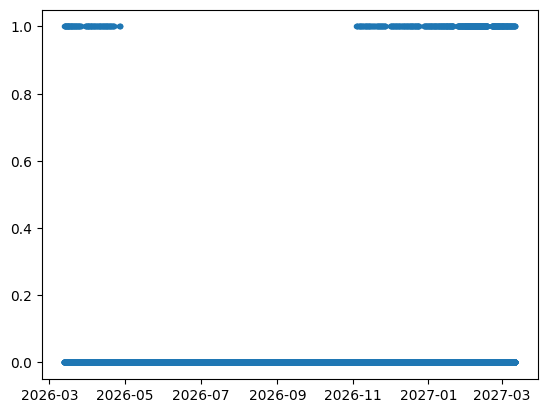

In [19]:
plt.plot(plot_a["Time_UTC"], plot_a["Visible"] - plot_b["Visible"], '.')

# plt.plot(plot_b["Time_UTC"], plot_b["Visible"])

In [15]:
for ii in zip(plot_a["Visible"][0:100]-plot_b["Visible"][0:100]):
    print(ii)

(1.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(1.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(1.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(1.0,)
(0.0,)
(1.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(1.0,)
(0.0,)
(1.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(1.0,)
(0.0,)
(1.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(1.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(1.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
(0.0,)
